# AMN Models - QP


In [2]:
from Library.Build_Model_lite import *


DIRECTORY = '../../'
font = 'arial'
# We declare this function here and not in the
# function-storing python file to modify it easily
# as it can change the printouts of the methods
def printout(filename, Stats, model, time): 
    # printing Stats
    print('Stats for %s CPU-time %.4f' % (filename, time))
    print('R2 = %.4f (+/- %.4f) Constraint = %.4f (+/- %.4f)' % \
          (Stats.train_objective[0], Stats.train_objective[1],
           Stats.train_loss[0], Stats.train_loss[1]))
    print('Q2 = %.4f (+/- %.4f) Constraint = %.4f (+/- %.4f)' % \
          (Stats.test_objective[0], Stats.test_objective[1],
           Stats.test_loss[0], Stats.test_loss[1]))

In [6]:
import shutil
import numpy as np

# Create, train and evaluate AMN_QP o models with FBA simulated training set for E. coli core
# with EB or UB with a mechanistic layer

# What you can change 
seed = 10
ratio_test = 0.2 # part of the training set removed for test
np.random.seed(seed=seed)  

strain = "WT"
trainname = f'{strain}_UB_200' # the training set file name
# size = int(trainname.split('_')[-1]) # number of runs must be lower than the number of element in trainname
# End of What you can change

# Create model and run GD for X and Y randomly drawn from trainingfile
trainingfile = DIRECTORY+'Dataset_model/'+trainname

# Copy the model without size
# remove the size part if present
new_train_name = "_".join(trainname.split('_')[:-1])

trainingfile = './Dataset_model/'+new_train_name
# copy the model and paste with new name
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".npz", trainingfile + ".npz")
shutil.copyfile(DIRECTORY+'Dataset_model/'+trainname + ".xml", trainingfile + ".xml")

print(f"Training and Testing file used: {trainingfile}")

biomass_reaction_name = 'BIOMASS_Ec_iML1515_core_75p37M'
# Get the target index for biomass reaction
train_parameter = TrainingSet()
train_parameter.load(trainingfile)
target_index = [r.id for r in train_parameter.model.reactions].index(biomass_reaction_name)
# size = original_parameter.Y.shape[0]

# End of What you can change
  


model = Neural_Model(trainingfile = trainingfile, 
                     objective=[biomass_reaction_name],  
                     model_type='AMN_QP', 
                     timestep = 4, # The number of time the iterative  schema is rolled out
                     learn_rate=0.01,
                     scaler=True,
                     n_hidden = 1, 
                     hidden_dim = 500,
                     epochs=25, 
                     xfold=5,
                     verbose=True)
ID = np.random.choice(model.X.shape[0], 
                      size=int(model.X.shape[0]*ratio_test), replace=False)
Xtest,  Ytest  = model.X[ID,:], model.Y[ID,:]
Xtrain, Ytrain = np.delete(model.X, ID, axis=0), np.delete(model.Y, ID, axis=0)

model.printout()

# Train and evaluate
reservoirname = trainname+'_'+model.model_type
reservoirfile = DIRECTORY+'Reservoir/'+reservoirname
start_time = time.time()
model.X, model.Y = Xtrain, Ytrain
reservoir, pred, stats, history = train_evaluate_model(model, verbose=2)
delta_time = time.time() - start_time


# Printing cross-validation results
printout(reservoirname, stats, model, delta_time)

# Save, reload and run idependent test set
# reservoir.save(reservoirfile)
# reservoir.load(reservoirfile)
# reservoir.printout()
start_time = time.time()
reservoir.X, reservoir.Y = Xtest, Ytest
X, Y = model_input(reservoir, verbose=False)
pred, stats = evaluate_model(reservoir.model, X, Y, reservoir, verbose=False)
delta_time = time.time() - start_time
delta_time = time.time() - start_time
printout('Test set', stats, model, delta_time)


Training and Testing file used: ./Dataset_model/WT_UB
Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\..\..\Dataset_model\WT_UB_200.xml: True
Loading model from: c:\Users\rh2310\projects\amn_release\Lab_Notebooks\AMN\..\..\Dataset_model\WT_UB_200.xml: True
number of reactions:  3682 3682
number of metabolites:  1877
filtered measurements size:  1
training file: ./Dataset_model/WT_UB
model type: AMN_QP
model scaler: 1.0
model input dim: 46
model output dim: 1
model medium bound: UB
timestep: 4
training set size (19600, 46) (19600, 1)
nbr hidden layer: 1
hidden layer size: 500
activation function: relu
gradient learn rate: 0.01
gradient decay rate: 0.9
training epochs: 25
training regression: True
training learn rate: 0.001
training dropout: 0.25
training batch size: 5
training validation iter: 0
training xfold: 5
training early stopping: False
AMN scaler 24000.0
QP input shape (15680, 46) (15680, 4)
-------train [    0     1     2 ... 15676 15677 15678] (12544

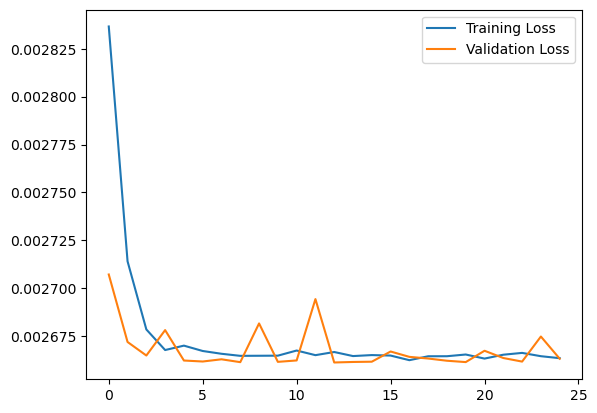

In [9]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [10]:
# To make the Ytest shape acceptable for evaluation, we augment it
# by adding zero constraints as vertical columns
# augmented_ytest = np.hstack( [Y, np.zeros((Ytest.shape[0], NBR_CONSTRAINT))] )
# y_pred, stats = evaluate_model(reservoir.model, test_parameter.X, test_parameter.Y, model, False, verbose=True)
# Get the inpuyt and output shapes for later slicing
param = copy.copy(model)
X, Y = model_input(param, verbose=True)
# yp is the model prediction of phenotype (growth rates)
end = Y.shape[1] - NBR_CONSTRAINT

AMN scaler 24000.0
QP input shape (15680, 46) (15680, 4)


---------- 1


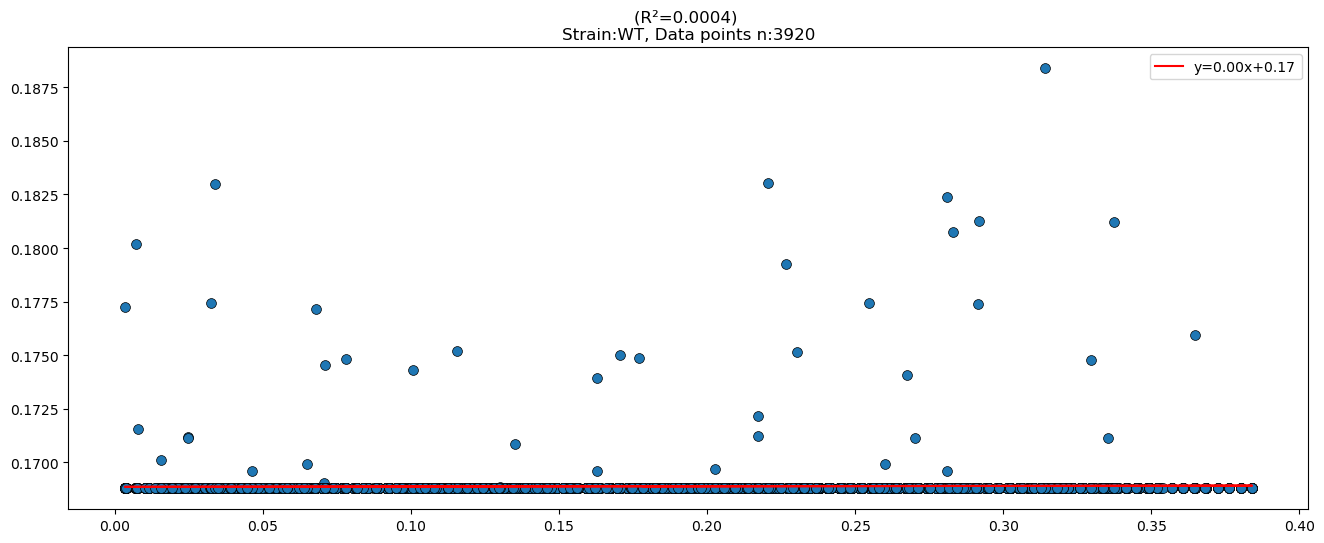

In [12]:
reservoir.X, reservoir.Y = Xtest, Ytest
# reservoir.b_ext, reservoir.b_int =  btest, bint
X, Y = model_input(reservoir,verbose=False)
pred, stats = evaluate_model(reservoir.model, X, Y, reservoir, verbose=False)
yp =  pred[:,:end]

y = np.array(yp.flatten())
x = np.array(Ytest).flatten()
m, b = np.polyfit(x, y, 1)
fig = plt.figure(figsize=(16,6))
ax1 = fig.subplots(1,1)
ax1.plot(x, m*x + b, color='red', label=f'y={m:.2f}x+{b:.2f}')
# find R2
correlation_matrix = np.corrcoef(x, y)
correlation_xy = correlation_matrix[0,1]
r_squared = correlation_xy**2

subtitle= (f"Strain:{strain}, Data points n:{y.shape[0]}")
ax1.set_title(f"(R²={r_squared:.4f}) \n"
              f"{subtitle}"
              )
ax1.scatter(x, y,s=50,edgecolors='black', linewidths=0.5)
plt.legend()

---------- 1


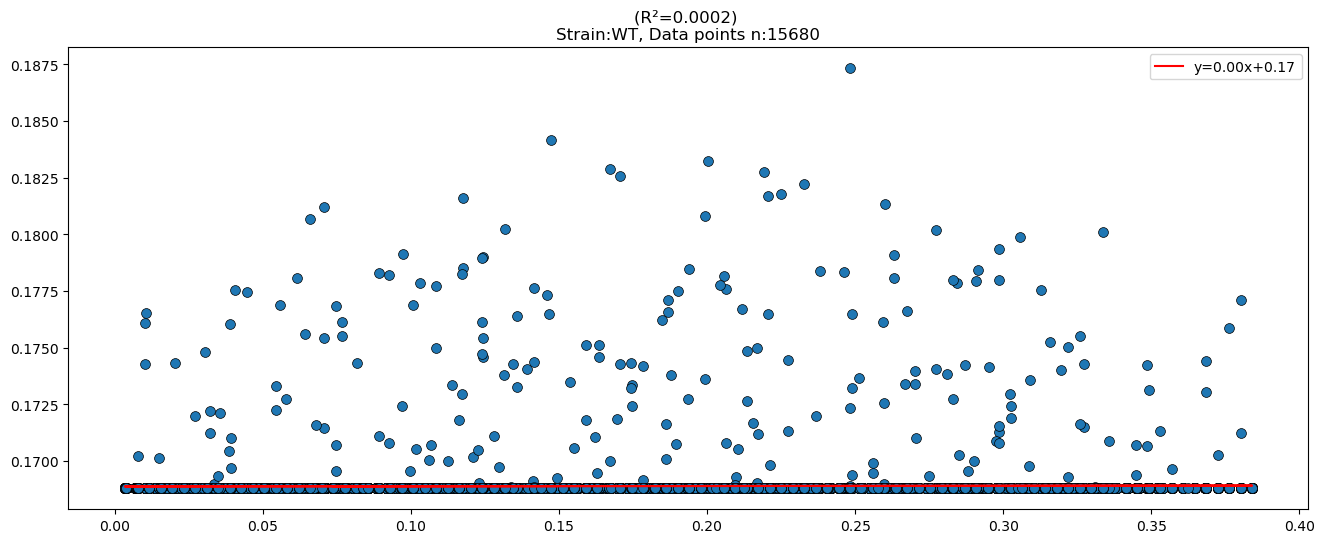

In [13]:
reservoir.X, reservoir.Y = Xtrain, Ytrain
# reservoir.b_ext, reservoir.b_int =  btrain, bint
X, Y = model_input(reservoir,verbose=False)
pred, stats = evaluate_model(reservoir.model, X, Y, reservoir, verbose=False)
yp =  pred[:,:end]

y = np.array(yp.flatten())
x = np.array(Ytrain).flatten()
m, b = np.polyfit(x, y, 1)
fig = plt.figure(figsize=(16,6))
ax1 = fig.subplots(1,1)
ax1.plot(x, m*x + b, color='red', label=f'y={m:.2f}x+{b:.2f}')
# find R2
correlation_matrix = np.corrcoef(x, y)
correlation_xy = correlation_matrix[0,1]
r_squared = correlation_xy**2

subtitle= (f"Strain:{strain}, Data points n:{y.shape[0]}")
ax1.set_title(f"(R²={r_squared:.4f}) \n"
              f"{subtitle}"
              )
ax1.scatter(x, y,s=50,edgecolors='black', linewidths=0.5)
plt.legend()

In [ ]:
reservoirname = trainname+'_'+model.model_type + '_paper_params'
reservoirfile = DIRECTORY+'Reservoir/'+reservoirname
reservoir.save(reservoirfile)

../../Reservoir/WT_UB_200_AMN_QP_paper_params_param.csv
